# Blood-Brain Barrier Penetration — Zero-shot XGBoost

Binary classification on the [BBB_Martins](https://tdcommons.ai/single_pred_tasks/adme/#bbb-blood-brain-barrier-martins-et-al) dataset.

**Task:** predict whether a molecule crosses the blood-brain barrier (1 = penetrates, 0 = does not).  
**Features:** 1 024-bit Morgan fingerprints (ECFP4) computed with RDKit.  
**Model:** `ZeroShotXGBClassifier` — no hyperparameter tuning, parameters chosen automatically from dataset statistics.

## 1. Dependencies

In [1]:
# Uncomment to install if needed
# !pip install rdkit zsxgboost

## 2. Load dataset

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/tdc/binary/bbb_martins.tab", sep="\t")
df = df.dropna(subset=["Drug", "Y"])
df["Y"] = df["Y"].astype(int)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Y"], random_state=42)

print(f"Train: {len(train_df):,}  Test: {len(test_df):,}")
print(f"Class distribution (train): {train_df['Y'].value_counts().to_dict()}")

Train: 1,631  Test: 408
Class distribution (train): {1: 1248, 0: 383}


## 3. Compute Morgan fingerprints

In [3]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


def smiles_to_ecfp4(smiles_list, n_bits=1024):
    """Convert a list of SMILES to a binary ECFP4 fingerprint matrix."""
    gen = _morgan_gen if n_bits == 1024 else rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
        else:
            fps.append(gen.GetFingerprintAsNumPy(mol).astype(np.uint8))
    return np.vstack(fps)


X_train = smiles_to_ecfp4(train_df["Drug"])
X_test  = smiles_to_ecfp4(test_df["Drug"])

y_train = train_df["Y"].values
y_test  = test_df["Y"].values

print(f"Fingerprint matrix shape: {X_train.shape}")
print(f"Sparsity: {(X_train == 0).mean():.1%}")

Fingerprint matrix shape: (1631, 1024)
Sparsity: 95.9%


## 4. Inspect the dataset profile

In [4]:
from zsxgboost.inspector import inspect

profile = inspect(X_train, y_train)
print(profile)

DatasetProfile(
  n_samples=1631, n_features=1024, n_p_ratio=1.59
  sparsity=0.959, is_sparse_counts=True
  binary_feature_fraction=1.000, feature_signal_strength=0.051
  task='binary_classification'
  imbalance_ratio=0.31
  feature_signal_p90=0.114
)


In [5]:
from zsxgboost.params import get_params

params = get_params(profile)
print("Zero-shot hyperparameters (internal preset):")
for k, v in params.items():
    print(f"  {k}: {v}")

Zero-shot hyperparameters (internal preset):
  tree_method: hist
  device: cpu
  learning_rate: 0.05
  n_estimators: 2000
  early_stopping_rounds: 100
  grow_policy: lossguide
  max_depth: 0
  max_leaves: 163
  min_child_weight: 1
  subsample: 0.8
  num_parallel_tree: 3
  colsample_bytree: 1.0
  colsample_bynode: 0.05
  reg_alpha: 0.5
  reg_lambda: 1.275
  gamma: 0.05
  max_bin: 64
  nthread: 10
  objective: binary:logistic
  scale_pos_weight: 0.3069
  eval_metric: auc


## 5. Train the classifier

In [6]:
import time
from zsxgboost import ZeroShotXGBClassifier

clf = ZeroShotXGBClassifier(portfolio=True, verbose=True)
t0 = time.time()
clf.fit(X_train, y_train)
t_zs = time.time() - t0

print(f"Winning preset : {clf.preset_name_}")
print(f"Best iteration : {clf.best_iteration_}")
print(f"Train time     : {t_zs:.1f}s")
if clf.portfolio_scores_:
    print("")
    print("Portfolio scores (1 fast ranking split):")
    for name, score in sorted(clf.portfolio_scores_.items(), key=lambda x: -x[1] if x[1] == x[1] else float("-inf")):
        marker = " <-- winner" if name == clf.preset_name_ else ""
        skipped = " (skipped: cost)" if score != score else ""
        print(f"  {name:12s}: {score:+.4f}{marker}{skipped}")


17:06:06 INFO     Binary classification | n=1631, p=1024 | imbalance_ratio=0.31 | sparse_counts=True | device=cpu

         DEBUG     Stage 1 budget: rounds=300, patience=30 (n_tr=1467, scale=1.00)

         DEBUG     flaml     : skipped (cost=1.88e+08 > budget=1.24e+08 [20× default])

         INFO     Stage 1: 4 presets in parallel (rounds=300, patience=30, nthread_each=2)  |  skipped=['flaml']

         INFO     Stage 1: done in 0.6s

...

         DEBUG    objective=binary:logistic | eval_metric=auc | lr=0.05 | colsample_bytree=1.0

         INFO     Phase 2: retraining on 1631 samples for 101 rounds (lr=0.05, max_bin=64)

17:06:12 DEBUG    Phase 2: done in 3.1s

         SUCCESS  Training complete | preset=internal | best_iteration=100

Winning preset : internal
Best iteration : 100
Train time     : 6.7s

Portfolio scores (1 fast ranking split):
  flaml       : +nan (skipped: cost)
  internal    : +0.9091 <-- winner
  rf_like     : +0.9063
  autogluon   : +0.8964
  default     : +0.8917


## 6. Evaluate on the test set

In [7]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report,
)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
baseline_pr  = y_test.mean()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["non-BBB", "BBB"]))

ROC-AUC : 0.9281
PR-AUC  : 0.9712

              precision    recall  f1-score   support

     non-BBB       0.79      0.78      0.79        96
         BBB       0.93      0.94      0.93       312

    accuracy                           0.90       408
   macro avg       0.86      0.86      0.86       408
weighted avg       0.90      0.90      0.90       408



## 7. Default Random Forest baseline

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42)
t0 = time.time()
rf.fit(X_train, y_train)
t_rf = time.time() - t0

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = rf.predict(X_test)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf  = average_precision_score(y_test, y_prob_rf)

print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"PR-AUC  : {pr_auc_rf:.4f}")
print(f"Train time: {t_rf:.1f}s")
print()
print(classification_report(y_test, y_pred_rf, target_names=["non-BBB", "BBB"]))
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)


ROC-AUC : 0.9290
PR-AUC  : 0.9703
Train time: 0.3s

              precision    recall  f1-score   support

     non-BBB       0.92      0.59      0.72        96
         BBB       0.89      0.98      0.93       312

    accuracy                           0.89       408
   macro avg       0.90      0.79      0.83       408
weighted avg       0.89      0.89      0.88       408



## 8. Default XGBoost baseline

In [9]:
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_default = XGBClassifier(scale_pos_weight=neg/pos, eval_metric="auc",
                             random_state=42, verbosity=0)
t0 = time.time()
xgb_default.fit(X_train, y_train)
t_xgb = time.time() - t0

y_prob_xgb0 = xgb_default.predict_proba(X_test)[:, 1]
y_pred_xgb0 = xgb_default.predict(X_test)

roc_auc_xgb0 = roc_auc_score(y_test, y_prob_xgb0)
pr_auc_xgb0  = average_precision_score(y_test, y_prob_xgb0)

print(f"ROC-AUC : {roc_auc_xgb0:.4f}")
print(f"PR-AUC  : {pr_auc_xgb0:.4f}")
print(f"Train time: {t_xgb:.1f}s")
print()
print(classification_report(y_test, y_pred_xgb0, target_names=["non-BBB", "BBB"]))
fpr_xgb0, tpr_xgb0, _ = roc_curve(y_test, y_prob_xgb0)
prec_xgb0, rec_xgb0, _ = precision_recall_curve(y_test, y_prob_xgb0)


ROC-AUC : 0.9266
PR-AUC  : 0.9710
Train time: 0.2s

              precision    recall  f1-score   support

     non-BBB       0.80      0.72      0.76        96
         BBB       0.92      0.95      0.93       312

    accuracy                           0.89       408
   macro avg       0.86      0.83      0.84       408
weighted avg       0.89      0.89      0.89       408



## 9. Logistic Regression baseline

In [10]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
t0 = time.time()
logreg.fit(X_train, y_train)
t_lr = time.time() - t0

y_prob_lr = logreg.predict_proba(X_test)[:, 1]
y_pred_lr = logreg.predict(X_test)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr  = average_precision_score(y_test, y_prob_lr)

print(f"ROC-AUC : {roc_auc_lr:.4f}")
print(f"PR-AUC  : {pr_auc_lr:.4f}")
print(f"Train time: {t_lr:.1f}s")
print()
print(classification_report(y_test, y_pred_lr, target_names=["non-BBB", "BBB"]))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)


ROC-AUC : 0.8947
PR-AUC  : 0.9451
Train time: 0.1s

              precision    recall  f1-score   support

     non-BBB       0.77      0.69      0.73        96
         BBB       0.91      0.94      0.92       312

    accuracy                           0.88       408
   macro avg       0.84      0.81      0.82       408
weighted avg       0.87      0.88      0.88       408



## 10. Results

In [11]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Zero-shot XGBoost",
        "Default XGBoost",
        "Default Random Forest",
        "Logistic Regression",
    ],
    "ROC-AUC":       [roc_auc,      roc_auc_xgb0, roc_auc_rf, roc_auc_lr],
    "PR-AUC":        [pr_auc,       pr_auc_xgb0,  pr_auc_rf,  pr_auc_lr],
    "Train time (s)": [t_zs,        t_xgb,        t_rf,       t_lr],
})
results = results.set_index("Model")
print(results.to_string(float_format="{:.4f}".format))

                       ROC-AUC  PR-AUC  Train time (s)
Model                                                 
Zero-shot XGBoost       0.9281  0.9712          6.6611
Default XGBoost         0.9266  0.9710          0.2270
Default Random Forest   0.9290  0.9703          0.2513
Logistic Regression     0.8947  0.9451          0.0690


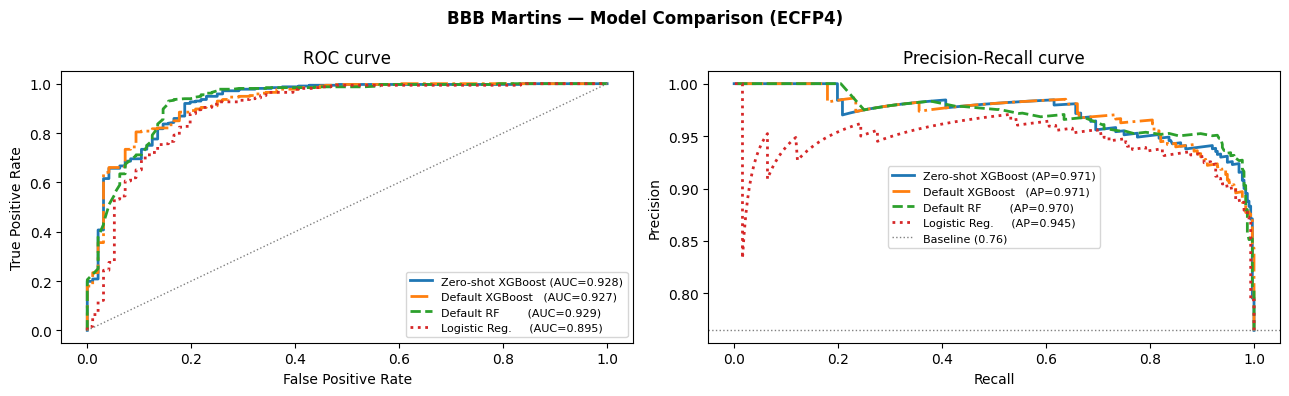

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROC
axes[0].plot(fpr,      tpr,      lw=2, label=f"Zero-shot XGBoost (AUC={roc_auc:.3f})")
axes[0].plot(fpr_xgb0, tpr_xgb0, lw=2, label=f"Default XGBoost   (AUC={roc_auc_xgb0:.3f})", linestyle="-.")
axes[0].plot(fpr_rf,   tpr_rf,   lw=2, label=f"Default RF        (AUC={roc_auc_rf:.3f})", linestyle="--")
axes[0].plot(fpr_lr,   tpr_lr,   lw=2, label=f"Logistic Reg.     (AUC={roc_auc_lr:.3f})", linestyle=":")
axes[0].plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve"); axes[0].legend(fontsize=8)

# PR
axes[1].plot(rec,      prec,      lw=2, label=f"Zero-shot XGBoost (AP={pr_auc:.3f})")
axes[1].plot(rec_xgb0, prec_xgb0, lw=2, label=f"Default XGBoost   (AP={pr_auc_xgb0:.3f})", linestyle="-.")
axes[1].plot(rec_rf,   prec_rf,   lw=2, label=f"Default RF        (AP={pr_auc_rf:.3f})", linestyle="--")
axes[1].plot(rec_lr,   prec_lr,   lw=2, label=f"Logistic Reg.     (AP={pr_auc_lr:.3f})", linestyle=":")
axes[1].axhline(baseline_pr, linestyle=":", color="grey", lw=1, label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(fontsize=8)

plt.suptitle("BBB Martins — Model Comparison (ECFP4)", fontweight="bold")
plt.tight_layout(); plt.show()